<a href="https://colab.research.google.com/github/HuyLuong2002/anfis-breast-cancer/blob/main/anfis_breast_cancer_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cài đặt thư viện



In [39]:
# Chạy cell này trước tiên (hỗ trợ local Windows/Linux/Mac)
import os
import sys
import subprocess
from pathlib import Path

PROJECT_ROOT = Path.cwd()
REPO_DIR = PROJECT_ROOT / "scikit-anfis"
VENV_DIR = PROJECT_ROOT / ".venv"

if not REPO_DIR.exists():
    subprocess.run(["git", "clone", "https://github.com/hudscomdz/scikit-anfis.git"], check=True)

# Tạo venv local (khuyến nghị để chạy notebook ổn định)
if os.name == "nt":
    venv_python = VENV_DIR / "Scripts" / "python.exe"
else:
    venv_python = VENV_DIR / "bin" / "python"

if not venv_python.exists():
    subprocess.run([sys.executable, "-m", "venv", str(VENV_DIR)], check=True)

# Cài dependencies vào venv
subprocess.run([str(venv_python), "-m", "pip", "install", "--upgrade", "pip"], check=True)
subprocess.run([str(venv_python), "-m", "pip", "install", "-r", str(REPO_DIR / "requirements.txt")], check=True)
subprocess.run([str(venv_python), "-m", "pip", "install", "-e", str(REPO_DIR)], check=True)

# Cài vào kernel hiện tại để notebook import được ngay
%pip install -q pandas numpy scikit-learn scipy matplotlib seaborn ucimlrepo
%pip install -q -e ./scikit-anfis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import set_config
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neural_network import MLPClassifier
from scipy.spatial.distance import mahalanobis
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import skanfis
from skanfis.membership import make_gauss_mfs

import warnings
warnings.filterwarnings('ignore')

# Tránh sklearn cố render estimator dạng HTML (gây lỗi với scikit-anfis custom class)
set_config(display="text")

np.random.seed(42)  # Đảm bảo kết quả tái lập được

Note: you may need to restart the kernel to use updated packages.
^C
Note: you may need to restart the kernel to use updated packages.


# Tiền xử lý dữ liệu cho mô hình đề xuất


In [76]:
# =========================
# Tiền xử lý cơ bản: missing values + loại nhiễu/outlier + chọn feature
# =========================
from pathlib import Path
from datetime import datetime

RUN_PRESETS = {
    "RUN_1": {"run_note": "Basic preprocessing - split 80/20", "test_size": 0.2, "random_state": 21, "epoch": 100, "top_k_features": 4},
    "RUN_2": {"run_note": "Basic preprocessing - split 70/30", "test_size": 0.3, "random_state": 21, "epoch": 100, "top_k_features": 4},
    "RUN_3": {"run_note": "Basic preprocessing - split 60/40", "test_size": 0.4, "random_state": 21, "epoch": 100, "top_k_features": 4},
}

ACTIVE_RUN = "RUN_3"
TRIAL_TAG = "lan_3"
CFG_OVERRIDES = {
    # "epoch": 150,
    # "top_k_features": 5,
}

CFG = {**RUN_PRESETS[ACTIVE_RUN], **CFG_OVERRIDES}
CFG["preset_name"] = ACTIVE_RUN
CFG["trial_tag"] = CFG.get("trial_tag", TRIAL_TAG)

log_dir = Path("nhat-ky")
log_dir.mkdir(parents=True, exist_ok=True)
model_dir = Path("models")
model_dir.mkdir(parents=True, exist_ok=True)

RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
ARTIFACT_BASENAME = f"{RUN_TIMESTAMP}_{CFG['trial_tag']}"

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"
cols = [
    "ID", "Clump_Thickness", "Uniformity_Cell_Size", "Uniformity_Cell_Shape",
    "Marginal_Adhesion", "Single_Epithelial_Cell_Size", "Bare_Nuclei",
    "Bland_Chromatin", "Normal_Nucleoli", "Mitoses", "Class"
]

df_raw = pd.read_csv(url, names=cols, na_values="?")
print(f"✅ Dữ liệu gốc: {df_raw.shape[0]} mẫu × {df_raw.shape[1]} cột")

# Bỏ ID vì không mang ý nghĩa dự đoán, bỏ bản ghi trùng để giảm nhiễu dữ liệu.
df = df_raw.drop(columns=["ID"]).drop_duplicates().copy()
df["Class"] = df["Class"].map({2: 0, 4: 1})  # 0: Benign, 1: Malignant

feature_names = df.drop(columns=["Class"]).columns.tolist()
X = df[feature_names]
y = df["Class"].astype(int).to_numpy()

# Điền dữ liệu trống bằng median vì các thuộc tính là thang điểm số 1-10.
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

# Loại nhiễu/outlier đơn giản bằng IQR trên từng feature.
q1 = np.percentile(X_imputed, 25, axis=0)
q3 = np.percentile(X_imputed, 75, axis=0)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outlier_mask = ((X_imputed < lower) | (X_imputed > upper)).any(axis=1)
X_clean = X_imputed[~outlier_mask]
y_clean = y[~outlier_mask]

# Chọn top-k feature để ANFIS không sinh quá nhiều luật mờ.
k = min(CFG["top_k_features"], X_clean.shape[1])
selector = SelectKBest(score_func=f_classif, k=k)
X_selected = selector.fit_transform(X_clean, y_clean)
selected_idx = selector.get_support(indices=True)
train_features = [feature_names[i] for i in selected_idx]

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y_clean,
    test_size=CFG["test_size"],
    random_state=CFG["random_state"],
    stratify=y_clean,
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("=" * 70)
print(f"🚀 Preset: {CFG['preset_name']} | {CFG['run_note']}")
print(f"🧪 Trial tag: {CFG['trial_tag']}")
print(f"✅ Sau bỏ trùng: {df.shape[0]} mẫu")
print(f"✅ Missing sau impute: {np.isnan(X_imputed).sum()}")
print(f"✅ Outlier đã loại: {outlier_mask.sum()} mẫu")
print(f"✅ Dữ liệu sạch: {X_clean.shape[0]} mẫu")
print(f"✅ Feature dùng để train ({len(train_features)}): {train_features}")
print(f"✅ Split: train={len(y_train)}, test={len(y_test)}")
print("=" * 70)

display(pd.DataFrame({
    "Feature": feature_names,
    "F_score": selector.scores_,
    "Used_for_train": ["YES" if name in train_features else "NO" for name in feature_names],
}).sort_values("F_score", ascending=False).style.set_caption("Điểm chọn đặc trưng bằng ANOVA F-test"))

✅ Dữ liệu gốc: 699 mẫu × 11 cột
🚀 Preset: RUN_3 | Basic preprocessing - split 60/40
🧪 Trial tag: lan_3
✅ Sau bỏ trùng: 463 mẫu
✅ Missing sau impute: 0
✅ Outlier đã loại: 70 mẫu
✅ Dữ liệu sạch: 393 mẫu
✅ Feature dùng để train (4): ['Uniformity_Cell_Size', 'Uniformity_Cell_Shape', 'Bare_Nuclei', 'Bland_Chromatin']
✅ Split: train=235, test=158


,Feature,F_score,Used_for_train
5,Bare_Nuclei,564.656653,YES
2,Uniformity_Cell_Shape,531.910033,YES
1,Uniformity_Cell_Size,479.457370,YES
6,Bland_Chromatin,396.492908,YES
0,Clump_Thickness,294.831213,NO
7,Normal_Nucleoli,269.251043,NO
3,Marginal_Adhesion,232.735849,NO
4,Single_Epithelial_Cell_Size,211.032190,NO
8,Mitoses,54.797967,NO


# Huấn luyện ANFIS bằng Hybrid Learning

Mô hình ANFIS được triển khai bằng `scikit-anfis` với `hybrid=True`. Về mặt báo cáo, phần này tương ứng với cơ chế học lai: bước tiến dùng Least Squares Estimation để tối ưu tham số hệ quả Sugeno, bước lùi dùng Gradient Descent / Backpropagation để cập nhật tham số tiền đề của các hàm thành viên.

In [77]:
# Huấn luyện ANFIS Hybrid Learning theo mẫu scikit-anfis
from skanfis import scikit_anfis
import json
import pickle

MEMBERSHIP_FUNCTIONS_PER_FEATURE = 3
EXPECTED_RULE_COUNT = MEMBERSHIP_FUNCTIONS_PER_FEATURE ** len(train_features)

# Mỗi feature có 3 mức mờ: Thấp - Trung bình - Cao.
# Với 4 feature, ANFIS sẽ sinh 3^4 = 81 luật mờ.
anfis_input_defs = []
for feature_idx in range(X_train_sc.shape[1]):
    centers = np.quantile(X_train_sc[:, feature_idx], [0.10, 0.50, 0.90]).tolist()
    sigma = max(float(np.std(X_train_sc[:, feature_idx]) / MEMBERSHIP_FUNCTIONS_PER_FEATURE), 0.10)
    anfis_input_defs.append((f"x{feature_idx}", make_gauss_mfs(sigma, centers)))

model = scikit_anfis(
    data=anfis_input_defs,
    description=f"Breast Cancer ANFIS - {CFG['preset_name']} - {CFG['trial_tag']}",
    epoch=CFG["epoch"],
    hybrid=True,
    label="c",
)

print("✅ Mô hình: ANFIS Hybrid Learning")
print("✅ Features:", train_features)
print("✅ Membership functions/feature:", MEMBERSHIP_FUNCTIONS_PER_FEATURE)
print("✅ Expected fuzzy rules:", EXPECTED_RULE_COUNT)
print("✅ Epoch:", CFG["epoch"])
print("✅ Train/Test:", X_train_sc.shape, X_test_sc.shape)

model.fit(X_train_sc, y_train)
print("✅ Huấn luyện ANFIS xong.")

model_path = model_dir / f"{ARTIFACT_BASENAME}_anfis.pkl"
scaler_path = model_dir / f"{ARTIFACT_BASENAME}_scaler.pkl"
meta_path = model_dir / f"{ARTIFACT_BASENAME}_meta.json"

model.save(str(model_path))
with scaler_path.open("wb") as f:
    pickle.dump(scaler, f)

meta = {
    "artifact_basename": ARTIFACT_BASENAME,
    "preset_name": CFG["preset_name"],
    "trial_tag": CFG["trial_tag"],
    "run_note": CFG["run_note"],
    "preprocessing": "drop ID, drop duplicates, median imputation, IQR outlier removal, StandardScaler, SelectKBest",
    "model": "ANFIS Hybrid Learning",
    "train_features": train_features,
    "test_size": CFG["test_size"],
    "random_state": CFG["random_state"],
    "epoch": CFG["epoch"],
    "membership_functions_per_feature": MEMBERSHIP_FUNCTIONS_PER_FEATURE,
    "expected_rule_count": EXPECTED_RULE_COUNT,
    "model_path": str(model_path.resolve()),
    "scaler_path": str(scaler_path.resolve()),
}
with meta_path.open("w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print(f"💾 Đã lưu model: {model_path}")
print(f"💾 Đã lưu scaler: {scaler_path}")
print(f"💾 Đã lưu metadata: {meta_path}")

✅ Mô hình: ANFIS Hybrid Learning
✅ Features: ['Uniformity_Cell_Size', 'Uniformity_Cell_Shape', 'Bare_Nuclei', 'Bland_Chromatin']
✅ Membership functions/feature: 3
✅ Expected fuzzy rules: 81
✅ Epoch: 100
✅ Train/Test: (235, 4) (158, 4)
✅ Huấn luyện ANFIS xong.
💾 Đã lưu model: models\20260611_152306_lan_3_anfis.pkl
💾 Đã lưu scaler: models\20260611_152306_lan_3_scaler.pkl
💾 Đã lưu metadata: models\20260611_152306_lan_3_meta.json


# Diễn giải ANFIS bằng luật mờ

Phần này làm rõ điểm khác biệt chính giữa ANFIS và Neural Network truyền thống: ANFIS không chỉ đưa ra nhãn dự đoán mà còn cho phép xem dữ liệu được mờ hóa, các luật mờ được kích hoạt, mức độ kích hoạt từng luật và diễn giải vì sao mẫu được dự đoán là Benign hoặc Malignant.

Với 4 feature đầu vào và mỗi feature có 3 mức mờ `Thấp`, `Trung bình`, `Cao`, tổng số luật mờ là `3^4 = 81`.

In [78]:
# Diễn giải ANFIS: mờ hóa dữ liệu, luật mờ, suy diễn và mẫu dự đoán sai
import json
import torch

CLASS_LABELS = {0: "Benign", 1: "Malignant"}
EXPLAIN_SAMPLE_LIMIT = 6
TOP_RULES_PER_SAMPLE = 5
BUSINESS_LABELS_BY_COUNT = {
    2: ["Thấp", "Cao"],
    3: ["Thấp", "Trung bình", "Cao"],
}

var_mfs = model.layer["fuzzify"].varmfs
feature_by_var = {var_name: train_features[i] for i, var_name in enumerate(var_mfs.keys())}


def get_center_value(mf_def):
    """Lấy tâm hàm thành viên để gán nhãn thấp/cao."""
    if hasattr(mf_def, "mu"):
        return float(mf_def.mu.detach().cpu().item())
    if hasattr(mf_def, "c"):
        return float(mf_def.c.detach().cpu().item())
    if hasattr(mf_def, "b"):
        return float(mf_def.b.detach().cpu().item())
    return np.nan


def get_param_value(mf_def, param_name):
    if hasattr(mf_def, param_name):
        return float(getattr(mf_def, param_name).detach().cpu().item())
    return np.nan


mf_business_label = {}
mf_rows = []
for feature_idx, (var_name, fuzz_var) in enumerate(var_mfs.items()):
    mf_centers = [
        (mf_name, get_center_value(mf_def))
        for mf_name, mf_def in fuzz_var.mfdefs.items()
    ]
    sorted_mfs = sorted(mf_centers, key=lambda item: item[1])
    business_labels = BUSINESS_LABELS_BY_COUNT.get(
        len(sorted_mfs),
        [f"Mức_{rank + 1}" for rank in range(len(sorted_mfs))],
    )
    label_map = {
        mf_name: business_labels[rank]
        for rank, (mf_name, _) in enumerate(sorted_mfs)
    }
    mf_business_label[var_name] = label_map

    for mf_name, mf_def in fuzz_var.mfdefs.items():
        center_scaled = get_center_value(mf_def)
        sigma_scaled = get_param_value(mf_def, "sigma")
        center_original = center_scaled * scaler.scale_[feature_idx] + scaler.mean_[feature_idx]
        mf_rows.append({
            "feature": feature_by_var[var_name],
            "biến_trong_mô_hình": var_name,
            "membership": mf_name,
            "nhãn_nghiệp_vụ": label_map[mf_name],
            "tâm_sau_chuẩn_hóa": round(center_scaled, 4),
            "độ_rộng_sigma": round(sigma_scaled, 4),
            "tâm_xấp_xỉ_trên_thang_gốc": round(float(center_original), 4),
        })

membership_df = pd.DataFrame(mf_rows)
display(
    membership_df.style
    .set_caption("1) Các hàm thành viên mờ sau huấn luyện: mf0/mf1/mf2 được diễn giải thành Thấp/Trung bình/Cao")
    .format({
        "tâm_sau_chuẩn_hóa": "{:.4f}",
        "độ_rộng_sigma": "{:.4f}",
        "tâm_xấp_xỉ_trên_thang_gốc": "{:.4f}",
    })
)

# Chạy forward trực tiếp để giữ đúng thứ tự mẫu test và lấy các tầng trung gian của ANFIS.
# scikit-anfis có cờ is_training riêng; cần tắt để forward không gọi fit_coeff khi không có y_actual.
model.eval()
model.is_training = False
X_test_tensor = torch.from_numpy(X_test_sc).float()
with torch.no_grad():
    anfis_score = model(X_test_tensor).detach().cpu().numpy().reshape(-1)

fuzzified_values = model.fuzzified.detach().cpu().numpy()
rule_fire_strength = model.raw_weights.detach().cpu().numpy()
rule_weight = model.weights.detach().cpu().numpy()
rule_output = model.rule_tsk.detach().cpu().numpy().squeeze(1)
y_pred_anfis_explain = np.clip(np.rint(np.abs(anfis_score)), 0, 1).astype(int)

# 1 mẫu sẽ được tách thành nhiều dòng: mỗi dòng là mức thuộc mờ của 1 feature.
fuzzy_rows = []
for sample_pos in range(min(10, len(X_test_sc))):
    for feature_idx, (var_name, fuzz_var) in enumerate(var_mfs.items()):
        mf_names = list(fuzz_var.mfdefs.keys())
        degrees = fuzzified_values[sample_pos, feature_idx, :len(mf_names)]
        dominant_idx = int(np.argmax(degrees))
        row = {
            "mẫu_test": sample_pos,
            "thực_tế": CLASS_LABELS[int(y_test[sample_pos])],
            "ANFIS_dự_đoán": CLASS_LABELS[int(y_pred_anfis_explain[sample_pos])],
            "điểm_ANFIS": round(float(anfis_score[sample_pos]), 4),
            "feature": feature_by_var[var_name],
            "giá_trị_gốc": round(float(X_test[sample_pos, feature_idx]), 4),
            "giá_trị_sau_chuẩn_hóa": round(float(X_test_sc[sample_pos, feature_idx]), 4),
            "mức_mờ_trội": mf_business_label[var_name][mf_names[dominant_idx]],
        }
        for mf_name, degree in zip(mf_names, degrees):
            label = mf_business_label[var_name][mf_name]
            row[f"độ_thuộc_{label}"] = round(float(degree), 4)
        fuzzy_rows.append(row)

fuzzy_data_df = pd.DataFrame(fuzzy_rows)
fuzzy_format = {
    col: "{:.4f}"
    for col in fuzzy_data_df.columns
    if col.startswith("độ_thuộc_") or col in ["điểm_ANFIS", "giá_trị_gốc", "giá_trị_sau_chuẩn_hóa"]
}
display(
    fuzzy_data_df.style
    .set_caption("2) Dữ liệu test sau khi được mờ hóa: mỗi feature có độ thuộc Thấp/Trung bình/Cao")
    .format(fuzzy_format)
)

# Danh sách luật: với 4 feature và 3 membership/feature sẽ có 3^4 = 81 luật.
rule_indices = model.layer["rules"].mf_indices.detach().cpu().numpy()
actual_rule_count = int(len(rule_indices))
expected_rule_count = int(np.prod([len(fuzz_var.mfdefs) for fuzz_var in var_mfs.values()]))
print(f"✅ Số luật mờ thực tế: {actual_rule_count} = {MEMBERSHIP_FUNCTIONS_PER_FEATURE}^{len(train_features)}")
if actual_rule_count != expected_rule_count:
    print(f"⚠️ Số luật thực tế ({actual_rule_count}) khác số luật kỳ vọng ({expected_rule_count}).")
rule_rows = []
for rule_idx, mf_idx_by_feature in enumerate(rule_indices):
    conditions = []
    for feature_idx, mf_idx in enumerate(mf_idx_by_feature):
        var_name = list(var_mfs.keys())[feature_idx]
        mf_name = list(var_mfs[var_name].mfdefs.keys())[int(mf_idx)]
        conditions.append(f"{feature_by_var[var_name]} {mf_business_label[var_name][mf_name]}")

    mean_output = float(np.mean(rule_output[:, rule_idx]))
    dominant_class = 1 if mean_output >= 0.5 else 0
    rule_rows.append({
        "luật": f"R{rule_idx + 1}",
        "IF": " AND ".join(conditions),
        "THEN_nghiêng_về": CLASS_LABELS[dominant_class],
        "đầu_ra_Sugeno_trung_bình": round(mean_output, 4),
        "độ_kích_hoạt_tb": round(float(np.mean(rule_weight[:, rule_idx])), 4),
        "độ_kích_hoạt_lớn_nhất": round(float(np.max(rule_weight[:, rule_idx])), 4),
        "số_lần_là_luật_mạnh_nhất": int(np.sum(np.argmax(rule_weight, axis=1) == rule_idx)),
    })

fuzzy_rules_df = pd.DataFrame(rule_rows)
display(
    fuzzy_rules_df.sort_values("số_lần_là_luật_mạnh_nhất", ascending=False).style
    .set_caption("3) Các luật mờ của ANFIS và mức độ được kích hoạt trên tập test")
    .format({
        "đầu_ra_Sugeno_trung_bình": "{:.4f}",
        "độ_kích_hoạt_tb": "{:.4f}",
        "độ_kích_hoạt_lớn_nhất": "{:.4f}",
    })
)

# Ưu tiên giải thích các mẫu ANFIS dự đoán sai; nếu ít mẫu sai thì thêm vài mẫu đúng để minh họa.
wrong_sample_positions = np.where(y_pred_anfis_explain != y_test)[0].tolist()
correct_sample_positions = np.where(y_pred_anfis_explain == y_test)[0].tolist()
samples_to_explain = (wrong_sample_positions + correct_sample_positions)[:EXPLAIN_SAMPLE_LIMIT]

sample_summary_rows = []
rule_trace_rows = []
rule_text_by_id = fuzzy_rules_df.set_index("luật")["IF"].to_dict()
for sample_pos in samples_to_explain:
    status = "Sai" if y_pred_anfis_explain[sample_pos] != y_test[sample_pos] else "Đúng"
    top_rule_indices = np.argsort(rule_weight[sample_pos])[::-1][:TOP_RULES_PER_SAMPLE]
    top_rule_names = [f"R{i + 1}" for i in top_rule_indices]
    sample_summary_rows.append({
        "mẫu_test": int(sample_pos),
        "kết_quả": status,
        "thực_tế": CLASS_LABELS[int(y_test[sample_pos])],
        "ANFIS_dự_đoán": CLASS_LABELS[int(y_pred_anfis_explain[sample_pos])],
        "điểm_ANFIS": round(float(anfis_score[sample_pos]), 4),
        "các_luật_tác_động_mạnh": ", ".join(top_rule_names),
    })
    for rank, rule_idx in enumerate(top_rule_indices, start=1):
        rule_name = f"R{rule_idx + 1}"
        contribution = float(rule_weight[sample_pos, rule_idx] * rule_output[sample_pos, rule_idx])
        rule_trace_rows.append({
            "mẫu_test": int(sample_pos),
            "xếp_hạng_luật": rank,
            "luật": rule_name,
            "điều_kiện_luật": rule_text_by_id[rule_name],
            "độ_kích_hoạt_chuẩn_hóa": round(float(rule_weight[sample_pos, rule_idx]), 4),
            "đầu_ra_luật_Sugeno": round(float(rule_output[sample_pos, rule_idx]), 4),
            "đóng_góp_vào_điểm_cuối": round(contribution, 4),
        })

sample_summary_df = pd.DataFrame(sample_summary_rows)
rule_trace_df = pd.DataFrame(rule_trace_rows)

display(
    sample_summary_df.style
    .set_caption("4) Các mẫu được giải thích: ưu tiên mẫu ANFIS dự đoán sai")
    .format({"điểm_ANFIS": "{:.4f}"})
)

display(
    rule_trace_df.style
    .set_caption("5) Suy diễn chi tiết: mỗi mẫu dựa mạnh nhất trên các luật nào")
    .format({
        "độ_kích_hoạt_chuẩn_hóa": "{:.4f}",
        "đầu_ra_luật_Sugeno": "{:.4f}",
        "đóng_góp_vào_điểm_cuối": "{:.4f}",
    })
)

print("✅ Tóm tắt diễn giải ANFIS")
print(f"- Số luật mờ: {len(fuzzy_rules_df)}")
print(f"- Số mẫu test ANFIS dự đoán sai: {len(wrong_sample_positions)} / {len(y_test)}")
print(f"- Các mẫu đang giải thích: {samples_to_explain}")
print("- Cách đọc: độ kích hoạt càng cao thì luật đó càng ảnh hưởng mạnh tới điểm ANFIS của mẫu.")

top_rules_for_meta = json.loads(
    fuzzy_rules_df
    .sort_values("số_lần_là_luật_mạnh_nhất", ascending=False)
    .head(5)
    .to_json(orient="records", force_ascii=False)
)
ANFIS_INTERPRETABILITY = {
    "rule_count": int(len(fuzzy_rules_df)),
    "misclassified_test_samples": int(len(wrong_sample_positions)),
    "explained_test_sample_positions": [int(x) for x in samples_to_explain],
    "top_rules_by_activation": top_rules_for_meta,
}

if "meta_path" in globals():
    if meta_path.exists():
        with meta_path.open("r", encoding="utf-8") as f:
            meta = json.load(f)
    else:
        meta = {}
    meta["anfis_interpretability"] = ANFIS_INTERPRETABILITY
    with meta_path.open("w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)
    print(f"🗂️ Đã cập nhật phần diễn giải ANFIS vào metadata: {meta_path}")

,feature,biến_trong_mô_hình,membership,nhãn_nghiệp_vụ,tâm_sau_chuẩn_hóa,độ_rộng_sigma,tâm_xấp_xỉ_trên_thang_gốc
0,Uniformity_Cell_Size,x0,mf0,Thấp,-1.0361,0.1725,0.4606
1,Uniformity_Cell_Size,x0,mf1,Trung bình,-0.3535,0.2840,2.4671
2,Uniformity_Cell_Size,x0,mf2,Cao,1.4579,0.4017,7.7921
3,Uniformity_Cell_Shape,x1,mf0,Thấp,-0.8127,0.4685,1.3220
4,Uniformity_Cell_Shape,x1,mf1,Trung bình,-0.0309,0.3991,3.5133
5,Uniformity_Cell_Shape,x1,mf2,Cao,1.4683,0.4888,7.7156
6,Bare_Nuclei,x2,mf0,Thấp,-0.8243,0.2759,1.1328
7,Bare_Nuclei,x2,mf1,Trung bình,-0.3326,0.5105,2.9624
8,Bare_Nuclei,x2,mf2,Cao,1.6962,0.2601,10.5115
9,Bland_Chromatin,x3,mf0,Trung bình,-0.7517,0.6156,1.9858


,mẫu_test,thực_tế,ANFIS_dự_đoán,điểm_ANFIS,feature,giá_trị_gốc,giá_trị_sau_chuẩn_hóa,mức_mờ_trội,độ_thuộc_Thấp,độ_thuộc_Trung bình,độ_thuộc_Cao
0,0,Benign,Benign,-0.0000,Uniformity_Cell_Size,1.0000,-0.8526,Thấp,0.5678,0.2134,0.0000
1,0,Benign,Benign,-0.0000,Uniformity_Cell_Shape,1.0000,-0.9276,Thấp,0.9704,0.0801,0.0000
2,0,Benign,Benign,-0.0000,Bare_Nuclei,1.0000,-0.8600,Thấp,0.9917,0.5864,0.0000
3,0,Benign,Benign,-0.0000,Bland_Chromatin,1.0000,-1.1366,Trung bình,0.0000,0.8224,0.0000
4,1,Malignant,Benign,0.0000,Uniformity_Cell_Size,6.0000,0.8483,Cao,0.0000,0.0001,0.3162
5,1,Malignant,Benign,0.0000,Uniformity_Cell_Shape,6.0000,0.8562,Cao,0.0018,0.0845,0.4566
6,1,Malignant,Benign,0.0000,Bare_Nuclei,5.0000,0.2150,Trung bình,0.0008,0.5625,0.0000
7,1,Malignant,Benign,0.0000,Bland_Chromatin,3.0000,-0.3556,Trung bình,0.0000,0.8131,0.0000
8,2,Benign,Benign,0.0000,Uniformity_Cell_Size,4.0000,0.1679,Trung bình,0.0000,0.1852,0.0058
9,2,Benign,Benign,0.0000,Uniformity_Cell_Shape,4.0000,0.1427,Trung bình,0.1251,0.9097,0.0253


✅ Số luật mờ thực tế: 81 = 3^4


,luật,IF,THEN_nghiêng_về,đầu_ra_Sugeno_trung_bình,độ_kích_hoạt_tb,độ_kích_hoạt_lớn_nhất,số_lần_là_luật_mạnh_nhất
0,R1,Uniformity_Cell_Size Thấp AND Uniformity_Cell_Shape Thấp AND Bare_Nuclei Thấp AND Bland_Chromatin Trung bình,Benign,-0.0000,0.0910,0.4219,31
80,R81,Uniformity_Cell_Size Cao AND Uniformity_Cell_Shape Cao AND Bare_Nuclei Cao AND Bland_Chromatin Cao,Benign,0.0000,0.0986,0.9988,17
3,R4,Uniformity_Cell_Size Thấp AND Uniformity_Cell_Shape Thấp AND Bare_Nuclei Trung bình AND Bland_Chromatin Trung bình,Benign,-0.0001,0.1005,0.6704,15
27,R28,Uniformity_Cell_Size Trung bình AND Uniformity_Cell_Shape Thấp AND Bare_Nuclei Thấp AND Bland_Chromatin Trung bình,Benign,0.0002,0.0878,0.5803,14
77,R78,Uniformity_Cell_Size Cao AND Uniformity_Cell_Shape Cao AND Bare_Nuclei Trung bình AND Bland_Chromatin Cao,Benign,0.0000,0.0523,0.9975,9
42,R43,Uniformity_Cell_Size Trung bình AND Uniformity_Cell_Shape Trung bình AND Bare_Nuclei Cao AND Bland_Chromatin Trung bình,Benign,-0.0000,0.0448,0.8557,9
78,R79,Uniformity_Cell_Size Cao AND Uniformity_Cell_Shape Cao AND Bare_Nuclei Cao AND Bland_Chromatin Trung bình,Benign,-0.0000,0.0494,0.9975,9
39,R40,Uniformity_Cell_Size Trung bình AND Uniformity_Cell_Shape Trung bình AND Bare_Nuclei Trung bình AND Bland_Chromatin Trung bình,Benign,0.0004,0.0627,0.7672,8
9,R10,Uniformity_Cell_Size Thấp AND Uniformity_Cell_Shape Trung bình AND Bare_Nuclei Thấp AND Bland_Chromatin Trung bình,Benign,-0.0002,0.0265,0.3920,6
30,R31,Uniformity_Cell_Size Trung bình AND Uniformity_Cell_Shape Thấp AND Bare_Nuclei Trung bình AND Bland_Chromatin Trung bình,Benign,0.0006,0.0898,0.6780,5


,mẫu_test,kết_quả,thực_tế,ANFIS_dự_đoán,điểm_ANFIS,các_luật_tác_động_mạnh
0,1,Sai,Malignant,Benign,0.0000,"R76, R67, R58, R73, R49"
1,3,Sai,Malignant,Benign,0.0000,"R78, R75, R76, R69, R60"
2,4,Sai,Malignant,Benign,0.0000,"R81, R72, R79, R63, R70"
3,5,Sai,Malignant,Benign,-0.0000,"R79, R81, R70, R76, R72"
4,6,Sai,Malignant,Benign,0.0000,"R73, R76, R75, R78, R64"
5,9,Sai,Malignant,Benign,0.0000,"R36, R45, R33, R34, R42"


,mẫu_test,xếp_hạng_luật,luật,điều_kiện_luật,độ_kích_hoạt_chuẩn_hóa,đầu_ra_luật_Sugeno,đóng_góp_vào_điểm_cuối
0,1,1,R76,Uniformity_Cell_Size Cao AND Uniformity_Cell_Shape Cao AND Bare_Nuclei Trung bình AND Bland_Chromatin Trung bình,0.8395,0.0000,0.0000
1,1,2,R67,Uniformity_Cell_Size Cao AND Uniformity_Cell_Shape Trung bình AND Bare_Nuclei Trung bình AND Bland_Chromatin Trung bình,0.1554,0.0000,0.0000
2,1,3,R58,Uniformity_Cell_Size Cao AND Uniformity_Cell_Shape Thấp AND Bare_Nuclei Trung bình AND Bland_Chromatin Trung bình,0.0032,0.0000,0.0000
3,1,4,R73,Uniformity_Cell_Size Cao AND Uniformity_Cell_Shape Cao AND Bare_Nuclei Thấp AND Bland_Chromatin Trung bình,0.0012,0.0000,0.0000
4,1,5,R49,Uniformity_Cell_Size Trung bình AND Uniformity_Cell_Shape Cao AND Bare_Nuclei Trung bình AND Bland_Chromatin Trung bình,0.0003,-0.0000,-0.0000
5,3,1,R78,Uniformity_Cell_Size Cao AND Uniformity_Cell_Shape Cao AND Bare_Nuclei Trung bình AND Bland_Chromatin Cao,0.9975,0.0000,0.0000
6,3,2,R75,Uniformity_Cell_Size Cao AND Uniformity_Cell_Shape Cao AND Bare_Nuclei Thấp AND Bland_Chromatin Cao,0.0015,0.0000,0.0000
7,3,3,R76,Uniformity_Cell_Size Cao AND Uniformity_Cell_Shape Cao AND Bare_Nuclei Trung bình AND Bland_Chromatin Trung bình,0.0007,0.0000,0.0000
8,3,4,R69,Uniformity_Cell_Size Cao AND Uniformity_Cell_Shape Trung bình AND Bare_Nuclei Trung bình AND Bland_Chromatin Cao,0.0003,0.0000,0.0000
9,3,5,R60,Uniformity_Cell_Size Cao AND Uniformity_Cell_Shape Thấp AND Bare_Nuclei Trung bình AND Bland_Chromatin Cao,0.0000,0.0000,0.0000


✅ Tóm tắt diễn giải ANFIS
- Số luật mờ: 81
- Số mẫu test ANFIS dự đoán sai: 69 / 158
- Các mẫu đang giải thích: [1, 3, 4, 5, 6, 9]
- Cách đọc: độ kích hoạt càng cao thì luật đó càng ảnh hưởng mạnh tới điểm ANFIS của mẫu.
🗂️ Đã cập nhật phần diễn giải ANFIS vào metadata: models\20260611_152306_lan_3_meta.json


# Đánh giá và so sánh với Neural Network truyền thống

Phần này dùng cùng tập train/test và cùng dữ liệu đã chuẩn hóa để so sánh công bằng giữa ANFIS Hybrid Learning và mạng neural truyền thống dạng MLP.

# Huấn luyện Neural Network truyền thống

Cell này dùng MLPClassifier làm baseline neural network truyền thống, chạy trên cùng dữ liệu train/test đã chuẩn hóa với ANFIS.

In [79]:
# Huấn luyện Neural Network truyền thống
nn_model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=CFG["random_state"],
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30,
)

nn_model.fit(X_train_sc, y_train)
y_pred_nn = nn_model.predict(X_test_sc)

print("✅ Huấn luyện Neural Network MLP xong.")
print("✅ Accuracy:", accuracy_score(y_test, y_pred_nn))
print(classification_report(y_test, y_pred_nn, target_names=["Benign", "Malignant"], zero_division=0))

✅ Huấn luyện Neural Network MLP xong.
✅ Accuracy: 0.8987341772151899
              precision    recall  f1-score   support

      Benign       0.89      0.93      0.91        89
   Malignant       0.91      0.86      0.88        69

    accuracy                           0.90       158
   macro avg       0.90      0.89      0.90       158
weighted avg       0.90      0.90      0.90       158




📈 Kết quả tập Test - ANFIS Hybrid Learning
✅ Accuracy: 56.96%
              precision    recall  f1-score   support

      Benign       0.57      0.97      0.72        89
   Malignant       0.57      0.06      0.11        69

    accuracy                           0.57       158
   macro avg       0.57      0.51      0.41       158
weighted avg       0.57      0.57      0.45       158


📈 Kết quả tập Test - Neural Network MLP
✅ Accuracy: 89.87%
              precision    recall  f1-score   support

      Benign       0.89      0.93      0.91        89
   Malignant       0.91      0.86      0.88        69

    accuracy                           0.90       158
   macro avg       0.90      0.89      0.90       158
weighted avg       0.90      0.90      0.90       158



,model,accuracy,precision_malignant,recall_malignant,f1_malignant,macro_f1,weighted_f1,train_features,test_size
0,ANFIS Hybrid Learning,0.5696,0.5714,0.0580,0.1053,0.4110,0.4497,"Uniformity_Cell_Size, Uniformity_Cell_Shape, Bare_Nuclei, Bland_Chromatin",0.400000
1,Neural Network MLP,0.8987,0.9077,0.8551,0.8806,0.8963,0.8983,"Uniformity_Cell_Size, Uniformity_Cell_Shape, Bare_Nuclei, Bland_Chromatin",0.400000


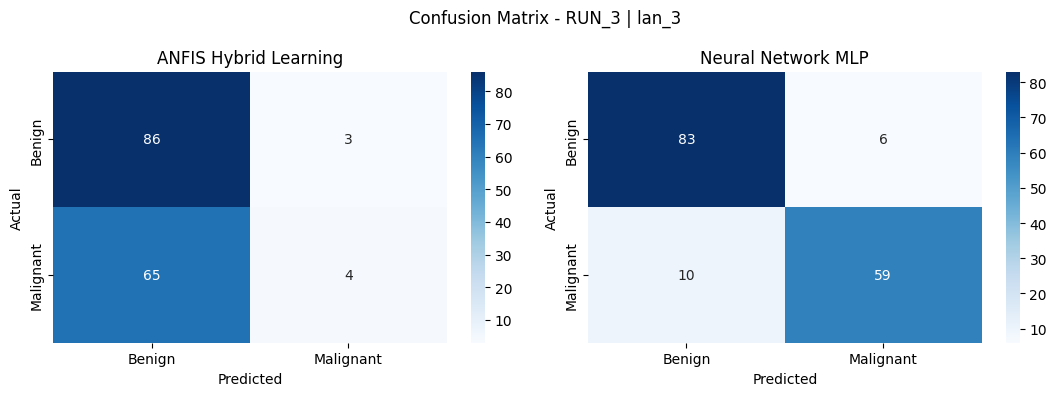

,preset_name,trial_tag,run_note,comparison_goal,anfis_accuracy,nn_accuracy,best_model_by_accuracy,test_size,epoch,top_k_features,train_features,preprocessing
0,RUN_3,lan_3,Basic preprocessing - split 60/40,ANFIS Hybrid Learning vs Neural Network truyền thống,0.569620,0.898734,Neural Network MLP,0.400000,100,4,"Uniformity_Cell_Size, Uniformity_Cell_Shape, Bare_Nuclei, Bland_Chromatin",median imputation + IQR outlier removal + StandardScaler


💾 Đã lưu Neural Network baseline: models\20260611_152306_lan_3_neural_network_mlp.pkl
🗂️ Đã cập nhật kết quả so sánh vào metadata: models\20260611_152306_lan_3_meta.json


In [80]:
# Đánh giá ANFIS Hybrid Learning và Neural Network truyền thống

def summarize_metrics(model_name, y_true, y_pred):
    report = classification_report(
        y_true,
        y_pred,
        target_names=['Benign', 'Malignant'],
        output_dict=True,
        zero_division=0,
    )
    cm_value = confusion_matrix(y_true, y_pred)
    return {
        "model": model_name,
        "accuracy": round(float(accuracy_score(y_true, y_pred)), 6),
        "precision_malignant": round(float(report['Malignant']['precision']), 6),
        "recall_malignant": round(float(report['Malignant']['recall']), 6),
        "f1_malignant": round(float(report['Malignant']['f1-score']), 6),
        "macro_f1": round(float(report['macro avg']['f1-score']), 6),
        "weighted_f1": round(float(report['weighted avg']['f1-score']), 6),
        "confusion_matrix": cm_value,
        "classification_report": report,
    }

# 1. ANFIS Hybrid Learning
anfis_pred_raw = model.predict(X_test_sc)
y_pred_anfis = np.clip(np.rint(np.squeeze(anfis_pred_raw)), 0, 1).astype(int)
anfis_result = summarize_metrics("ANFIS Hybrid Learning", y_test, y_pred_anfis)

# 2. Neural Network truyền thống đã được huấn luyện ở cell trước
y_pred_nn = nn_model.predict(X_test_sc)
nn_result = summarize_metrics("Neural Network MLP", y_test, y_pred_nn)

for result, y_pred_current in [(anfis_result, y_pred_anfis), (nn_result, y_pred_nn)]:
    print("\n" + "=" * 70)
    print(f"📈 Kết quả tập Test - {result['model']}")
    print("=" * 70)
    print(f"✅ Accuracy: {result['accuracy'] * 100:.2f}%")
    print(classification_report(y_test, y_pred_current, target_names=['Benign', 'Malignant'], zero_division=0))

comparison_rows = []
for result in [anfis_result, nn_result]:
    comparison_rows.append({
        "model": result["model"],
        "accuracy": result["accuracy"],
        "precision_malignant": result["precision_malignant"],
        "recall_malignant": result["recall_malignant"],
        "f1_malignant": result["f1_malignant"],
        "macro_f1": result["macro_f1"],
        "weighted_f1": result["weighted_f1"],
        "train_features": ", ".join(train_features),
        "test_size": CFG["test_size"],
    })

comparison_df = pd.DataFrame(comparison_rows)
display(
    comparison_df.style
    .set_caption("📌 So sánh ANFIS Hybrid Learning với Neural Network truyền thống")
    .format({
        "accuracy": "{:.4f}",
        "precision_malignant": "{:.4f}",
        "recall_malignant": "{:.4f}",
        "f1_malignant": "{:.4f}",
        "macro_f1": "{:.4f}",
        "weighted_f1": "{:.4f}",
    })
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, result in zip(axes, [anfis_result, nn_result]):
    sns.heatmap(
        result["confusion_matrix"],
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Benign', 'Malignant'],
        yticklabels=['Benign', 'Malignant'],
        ax=ax,
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(result["model"])
plt.suptitle(f"Confusion Matrix - {CFG['preset_name']} | {CFG['trial_tag']}")
plt.tight_layout()
plt.show()

RUN_RESULT = {
    "preset_name": CFG["preset_name"],
    "trial_tag": CFG["trial_tag"],
    "run_note": CFG["run_note"],
    "comparison_goal": "ANFIS Hybrid Learning vs Neural Network truyền thống",
    "anfis_accuracy": anfis_result["accuracy"],
    "nn_accuracy": nn_result["accuracy"],
    "best_model_by_accuracy": comparison_df.sort_values("accuracy", ascending=False).iloc[0]["model"],
    "test_size": CFG["test_size"],
    "epoch": CFG["epoch"],
    "top_k_features": CFG["top_k_features"],
    "train_features": ", ".join(train_features),
    "preprocessing": "median imputation + IQR outlier removal + StandardScaler",
}

display(pd.DataFrame([RUN_RESULT]).style.set_caption("📌 Tóm tắt kết quả run hiện tại"))

# Lưu baseline Neural Network và cập nhật metadata để truy vết kết quả so sánh
import json
import pickle

nn_model_path = model_dir / f"{ARTIFACT_BASENAME}_neural_network_mlp.pkl"
with nn_model_path.open("wb") as f:
    pickle.dump(nn_model, f)

meta_path = model_dir / f"{ARTIFACT_BASENAME}_meta.json"
if meta_path.exists():
    with meta_path.open("r", encoding="utf-8") as f:
        meta = json.load(f)
else:
    meta = {}

meta["comparison_goal"] = "ANFIS Hybrid Learning vs Neural Network truyền thống"
meta["anfis"] = {
    "accuracy": anfis_result["accuracy"],
    "confusion_matrix": anfis_result["confusion_matrix"].tolist(),
    "classification_report": anfis_result["classification_report"],
}
meta["neural_network_mlp"] = {
    "accuracy": nn_result["accuracy"],
    "confusion_matrix": nn_result["confusion_matrix"].tolist(),
    "classification_report": nn_result["classification_report"],
    "model_path": str(nn_model_path.resolve()),
    "hidden_layer_sizes": [16, 8],
}
meta["support"] = {"test_samples": int(len(y_test))}

with meta_path.open("w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print(f"💾 Đã lưu Neural Network baseline: {nn_model_path}")
print(f"🗂️ Đã cập nhật kết quả so sánh vào metadata: {meta_path}")

# Convert HTML

In [81]:
# Convert notebook sang HTML nhật ký (chạy local, ổn định)
import re
import sys
import subprocess
from datetime import datetime
from pathlib import Path

nb_path = Path("anfis_breast_cancer_model_training.ipynb").resolve()
log_dir = Path("nhat-ky").resolve()
log_dir.mkdir(parents=True, exist_ok=True)

safe_note = re.sub(r"[^a-zA-Z0-9_-]+", "_", CFG["run_note"].strip())[:40]
safe_trial = re.sub(r"[^a-zA-Z0-9_-]+", "_", str(CFG["trial_tag"]).strip())[:20]
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
out_name = f"{timestamp}_{safe_trial}_{safe_note}"
out_path = log_dir / f"{out_name}.html"

# Không phụ thuộc jupyter CLI: dùng nbconvert API trực tiếp
try:
    import nbformat
    from nbconvert import HTMLExporter
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "nbconvert", "nbformat"], check=True)
    import nbformat
    from nbconvert import HTMLExporter

with nb_path.open("r", encoding="utf-8") as f:
    nb_node = nbformat.read(f, as_version=4)

html_exporter = HTMLExporter()
html_body, _ = html_exporter.from_notebook_node(nb_node)
out_path.write_text(html_body, encoding="utf-8")

print(f"✅ Đã xuất HTML: {out_path}")

✅ Đã xuất HTML: C:\Hoc-tap\vs-workspace\py-workspace\anfis-breast-cancer\nhat-ky\20260611_152312_lan_3_Basic_preprocessing_-_split_60_40.html
